# Multiclass pipeline: one model per ESP + majority vote

This notebook builds a multiclass pipeline for `wifi_data_set_fixed` with labels:

- `label_00` -> 0
- `label_01` -> 1
- `label_02` -> 2
- `label_03` -> 3

Key idea:
1. Train a separate model for each ESP board (`dev1`, `dev2`, `dev3`).
2. For each `test_*` group, each ESP model gives one group prediction (majority vote over its files).
3. Final predicted class is majority vote across ESP model outputs.
4. Metrics are computed on this final cross-ESP majority prediction.

In [1]:
from pathlib import Path
import json
import re
import sys

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
import subprocess
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
try:
    from catboost import CatBoostClassifier
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'catboost', '-q'])
    from catboost import CatBoostClassifier

# Make project root importable so `tools` can be imported from notebooks/
project_root = Path.cwd()
if not (project_root.parent / 'tools').exists() and (project_root.parent.parent / 'tools').exists():
    project_root = project_root.parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from tools.csi_parser import Parser
from tools.filters import median_filter

# Main parameters
dataset_root = project_root / 'wifi_data_set_fixed_1fps'
median_width = 5  # must be odd
random_state = 42

if median_width % 2 == 0:
    raise ValueError('median_width must be odd')

np.random.seed(random_state)

label_to_class = {
    'label_00': 0,
    'label_01': 1,
    'label_02': 2,
    'label_03': 3,
}
class_to_label = {v: k for k, v in label_to_class.items()}

In [2]:
def extract_esp_id(file_path: Path) -> str:
    stem = file_path.stem
    match = re.search(r'dev(\d+)', stem, flags=re.IGNORECASE)
    if not match:
        raise ValueError(f'Could not extract ESP id from file name: {file_path.name}')
    return f'dev{int(match.group(1))}'


def parse_path_meta(file_path: Path) -> dict:
    parts = file_path.parts
    return {
        'person_id': next((p for p in parts if p.startswith('id_person_')), 'unknown'),
        'label': next((p for p in parts if p.startswith('label_')), 'unknown'),
        'test_id': next((p for p in parts if p.startswith('test_')), 'unknown'),
        'esp_id': extract_esp_id(file_path) if file_path.suffix == '.data' else 'unknown',
    }


def get_test_group_dir(file_path: Path) -> Path:
    # Group key: .../id_person_xx/label_xx/test_xx
    for parent in file_path.parents:
        if parent.name.startswith('test_'):
            return parent
    raise ValueError(f'Could not find test_* folder in path: {file_path}')


def skewness(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float64)
    mu = x.mean()
    sigma = x.std()
    if sigma == 0:
        return 0.0
    z = (x - mu) / sigma
    return float(np.mean(z ** 3))


def kurtosis_excess(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float64)
    mu = x.mean()
    sigma = x.std()
    if sigma == 0:
        return 0.0
    z = (x - mu) / sigma
    return float(np.mean(z ** 4) - 3.0)


def spectral_features(signal: np.ndarray) -> tuple[float, float, float, float, float]:
    x = np.asarray(signal, dtype=np.float64)
    n = len(x)
    if n < 2:
        return 0.0, 0.0, 0.0, 0.0, 0.0

    spectrum = np.fft.rfft(x)
    power = np.abs(spectrum) ** 2
    freqs = np.fft.rfftfreq(n, d=1.0)

    power_sum = power.sum()
    if power_sum <= 0:
        return 0.0, 0.0, 0.0, 0.0, 0.0

    centroid = float((freqs * power).sum() / power_sum)
    spread = float(np.sqrt(((freqs - centroid) ** 2 * power).sum() / power_sum))

    p_norm = power / power_sum
    eps = 1e-12
    entropy = float(-(p_norm * np.log2(p_norm + eps)).sum())

    dominant_idx = int(np.argmax(power))
    dominant_freq = float(freqs[dominant_idx])
    rolloff_threshold = 0.85 * power_sum
    rolloff = float(freqs[np.searchsorted(np.cumsum(power), rolloff_threshold)])

    return centroid, spread, entropy, dominant_freq, rolloff


def build_unit_signal(df: pd.DataFrame, window: int) -> np.ndarray:
    amp_matrix = np.stack(df['amplitude'].to_numpy(), axis=0).astype(np.float64)
    raw_time_signal = amp_matrix.mean(axis=1)
    return median_filter(raw_time_signal, window)


def build_unit_cache(file_list: list[Path]) -> list[dict]:
    cache = []
    for file_path in file_list:
        df = Parser(file_path).parse()
        filtered_signal = build_unit_signal(df, median_width)
        cache.append({
            'file_path': file_path,
            'df': df,
            'filtered_signal': filtered_signal,
        })
    return cache

In [3]:
all_files = sorted(dataset_root.rglob('*.data'))
if not all_files:
    raise FileNotFoundError(f'No .data files found under {dataset_root}')

file_rows = []
for fp in all_files:
    meta = parse_path_meta(fp)
    file_rows.append({
        'file_path': fp,
        'group_path': get_test_group_dir(fp),
        'label': meta['label'],
        'esp_id': meta['esp_id'],
    })

files_df = pd.DataFrame(file_rows)
esp_ids = sorted(files_df['esp_id'].unique())

all_groups = sorted(files_df['group_path'].unique())
group_labels = [parse_path_meta(group_path)['label'] for group_path in all_groups]

train_groups, test_groups = train_test_split(
    all_groups,
    test_size=0.2,
    random_state=random_state,
    stratify=group_labels,
    shuffle=True,
)

train_group_set = set(train_groups)
test_group_set = set(test_groups)
shared_groups = train_group_set & test_group_set
if shared_groups:
    raise RuntimeError(f'Group leakage detected across split: {sorted(shared_groups)}')

esp_splits: dict[str, dict] = {}
for esp_id in esp_ids:
    esp_df = files_df[files_df['esp_id'] == esp_id].copy()

    train_files = sorted([fp for fp in esp_df['file_path'] if get_test_group_dir(fp) in train_group_set])
    test_files = sorted([fp for fp in esp_df['file_path'] if get_test_group_dir(fp) in test_group_set])

    train_unit_cache = build_unit_cache(train_files)
    test_unit_cache = build_unit_cache(test_files)

    global_min = min(float(np.min(unit['filtered_signal'])) for unit in train_unit_cache)
    global_max = max(float(np.max(unit['filtered_signal'])) for unit in train_unit_cache)

    esp_splits[esp_id] = {
        'train_files': train_files,
        'test_files': test_files,
        'train_unit_cache': train_unit_cache,
        'test_unit_cache': test_unit_cache,
        'global_min': global_min,
        'global_max': global_max,
    }

print(f'Total units (.data files): {len(all_files)}')
print(f'ESP ids found: {esp_ids}')
print(f'Total test_* groups: {len(all_groups)}')
print(f'Train groups: {len(train_groups)}')
print(f'Test groups: {len(test_groups)}')
for esp_id in esp_ids:
    split = esp_splits[esp_id]
    print(
        f"{esp_id}: train_units={len(split['train_unit_cache'])}, "
        f"test_units={len(split['test_unit_cache'])}, "
        f"global_min={split['global_min']:.6f}, global_max={split['global_max']:.6f}"
    )

Total units (.data files): 24000
ESP ids found: ['dev1', 'dev2', 'dev3']
Total test_* groups: 8000
Train groups: 6400
Test groups: 1600
dev1: train_units=6400, test_units=1600, global_min=1.184494, global_max=29.857592
dev2: train_units=6400, test_units=1600, global_min=3.374140, global_max=39.403599
dev3: train_units=6400, test_units=1600, global_min=0.494638, global_max=14.640834


In [4]:
def build_features_df(unit_cache: list[dict], global_min: float, global_max: float) -> pd.DataFrame:
    den = global_max - global_min
    if den <= 0:
        raise ValueError('Global max equals global min; cannot perform min-max scaling')

    rows = []
    for unit in unit_cache:
        file_path = unit['file_path']
        df = unit['df']
        signal = unit['filtered_signal']

        scaled_signal = (signal - global_min) / den
        scaled_signal = np.clip(scaled_signal, 0.0, 1.0)

        mean_val = float(np.mean(scaled_signal))
        std_val = float(np.std(scaled_signal))
        median_val = float(np.median(scaled_signal))
        min_val = float(np.min(scaled_signal))
        max_val = float(np.max(scaled_signal))
        q25 = float(np.percentile(scaled_signal, 25))
        q75 = float(np.percentile(scaled_signal, 75))
        iqr = q75 - q25
        range_val = max_val - min_val
        rms = float(np.sqrt(np.mean(scaled_signal ** 2)))
        energy = float(np.sum(scaled_signal ** 2))
        zcr = float(np.mean(np.abs(np.diff(np.signbit(scaled_signal - mean_val)).astype(np.int8))))

        sk = skewness(scaled_signal)
        kt = kurtosis_excess(scaled_signal)
        sc, ss, se, dom_freq, rolloff = spectral_features(scaled_signal)

        meta = parse_path_meta(file_path)
        rows.append({
            'file_path': str(file_path),
            'group_path': str(get_test_group_dir(file_path)),
            **meta,
            'n_packets': int(len(df)),
            'mean': mean_val,
            'std': std_val,
            'median': median_val,
            'skew': sk,
            'kurtosis': kt,
            'spectral_centroid': sc,
            'spectral_spread': ss,
            'spectral_entropy': se,
            'dominant_freq': dom_freq,
            'spectral_rolloff_85': rolloff,
            'min': min_val,
            'max': max_val,
            'q25': q25,
            'q75': q75,
            'iqr': iqr,
            'range': range_val,
            'rms': rms,
            'energy': energy,
            'zcr': zcr,
        })

    return pd.DataFrame(rows)


feature_cols = [
    'mean', 'std', 'median', 'skew', 'kurtosis',
    'spectral_centroid', 'spectral_spread', 'spectral_entropy',
    'dominant_freq', 'spectral_rolloff_85',
    'min', 'max', 'q25', 'q75', 'iqr', 'range',
    'rms', 'energy', 'zcr',
]

esp_artifacts: dict[str, dict] = {}
for esp_id in esp_ids:
    split = esp_splits[esp_id]

    train_features_df = build_features_df(
        split['train_unit_cache'],
        split['global_min'],
        split['global_max'],
    )
    test_features_df = build_features_df(
        split['test_unit_cache'],
        split['global_min'],
        split['global_max'],
    )

    esp_artifacts[esp_id] = {
        'train_features_df': train_features_df,
        'test_features_df': test_features_df,
        'global_min': split['global_min'],
        'global_max': split['global_max'],
    }

    print(
        f"{esp_id}: train_features={train_features_df.shape}, "
        f"test_features={test_features_df.shape}"
    )

# Quick preview from first ESP
display(esp_artifacts[esp_ids[0]]['train_features_df'].head())

dev1: train_features=(6400, 26), test_features=(1600, 26)
dev2: train_features=(6400, 26), test_features=(1600, 26)
dev3: train_features=(6400, 26), test_features=(1600, 26)


,file_path,group_path,person_id,label,test_id,esp_id,n_packets,mean,std,median,...,spectral_rolloff_85,min,max,q25,q75,iqr,range,rms,energy,zcr
0,/home/gleb/learning/CSI-activity-detection/wif...,/home/gleb/learning/CSI-activity-detection/wif...,id_person_01,label_00,test_01_1,dev1,20,0.619699,0.061641,0.645988,...,0.0,0.524321,0.677970,0.557218,0.673010,0.115792,0.153648,0.622757,7.756519,0.105263
1,/home/gleb/learning/CSI-activity-detection/wif...,/home/gleb/learning/CSI-activity-detection/wif...,id_person_01,label_00,test_01_3,dev1,20,0.586403,0.037126,0.591700,...,0.0,0.513966,0.649106,0.559388,0.599871,0.040483,0.135140,0.587577,6.904935,0.105263
2,/home/gleb/learning/CSI-activity-detection/wif...,/home/gleb/learning/CSI-activity-detection/wif...,id_person_01,label_00,test_01_4,dev1,20,0.622562,0.036339,0.601764,...,0.0,0.585719,0.680580,0.590640,0.654258,0.063618,0.094861,0.623621,7.778069,0.210526
3,/home/gleb/learning/CSI-activity-detection/wif...,/home/gleb/learning/CSI-activity-detection/wif...,id_person_01,label_00,test_01_5,dev1,20,0.657695,0.031441,0.654050,...,0.0,0.613467,0.704780,0.630010,0.683057,0.053047,0.091313,0.658446,8.671026,0.105263
4,/home/gleb/learning/CSI-activity-detection/wif...,/home/gleb/learning/CSI-activity-detection/wif...,id_person_01,label_00,test_02_1,dev1,20,0.627036,0.083110,0.665431,...,0.0,0.491896,0.734723,0.531065,0.681964,0.150899,0.242827,0.632519,8.001616,0.105263


In [5]:
for esp_id in esp_ids:
    train_features_df = esp_artifacts[esp_id]['train_features_df']
    test_features_df = esp_artifacts[esp_id]['test_features_df']

    X_train_raw = train_features_df[feature_cols].to_numpy(dtype=np.float64)
    X_test_raw = test_features_df[feature_cols].to_numpy(dtype=np.float64)

    feature_min = X_train_raw.min(axis=0)
    feature_max = X_train_raw.max(axis=0)

    X_train = np.clip(X_train_raw, feature_min, feature_max)
    X_test = np.clip(X_test_raw, feature_min, feature_max)

    scaler_pca = StandardScaler()
    X_train_std = scaler_pca.fit_transform(X_train)
    X_test_std = scaler_pca.transform(X_test)

    pca = PCA()
    X_train_pca = pca.fit_transform(X_train_std)
    X_test_pca = pca.transform(X_test_std)

    evr = pca.explained_variance_ratio_
    cum_evr = np.cumsum(evr)
    k_95 = int(np.searchsorted(cum_evr, 0.95) + 1)

    X_train_pca_95 = X_train_pca[:, :k_95]
    X_test_pca_95 = X_test_pca[:, :k_95]

    train_label_mapped = train_features_df['label'].map(label_to_class)
    test_label_mapped = test_features_df['label'].map(label_to_class)

    if train_label_mapped.isna().any() or test_label_mapped.isna().any():
        observed_labels = set(train_features_df['label'].unique()) | set(test_features_df['label'].unique())
        unknown_labels = sorted(observed_labels - set(label_to_class))
        raise ValueError(f'Unexpected labels found for {esp_id}: {unknown_labels}')

    y_train = train_label_mapped.to_numpy(dtype=int)
    y_test = test_label_mapped.to_numpy(dtype=int)

    esp_artifacts[esp_id].update({
        'feature_min': feature_min,
        'feature_max': feature_max,
        'scaler_pca': scaler_pca,
        'pca': pca,
        'k_95': int(k_95),
        'X_train_pca_95': X_train_pca_95,
        'X_test_pca_95': X_test_pca_95,
        'y_train': y_train,
        'y_test': y_test,
    })

    print(
        f"{esp_id}: k_95={k_95}, X_train_pca_95={X_train_pca_95.shape}, "
        f"X_test_pca_95={X_test_pca_95.shape}"
    )

dev1: k_95=5, X_train_pca_95=(6400, 5), X_test_pca_95=(1600, 5)
dev2: k_95=6, X_train_pca_95=(6400, 6), X_test_pca_95=(1600, 6)
dev3: k_95=6, X_train_pca_95=(6400, 6), X_test_pca_95=(1600, 6)


In [6]:
esp_pca_summary = pd.DataFrame([
    {
        'esp_id': esp_id,
        'k_95': esp_artifacts[esp_id]['k_95'],
        'n_train': int(len(esp_artifacts[esp_id]['y_train'])),
        'n_test': int(len(esp_artifacts[esp_id]['y_test'])),
    }
    for esp_id in esp_ids
]).sort_values('esp_id').reset_index(drop=True)

esp_pca_summary

,esp_id,k_95,n_train,n_test
0,dev1,5,6400,1600
1,dev2,6,6400,1600
2,dev3,6,6400,1600


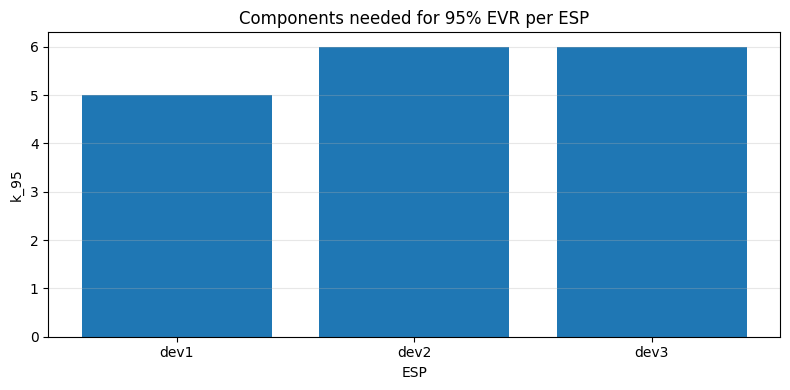

In [7]:
plt.figure(figsize=(8, 4))
plt.bar(esp_pca_summary['esp_id'], esp_pca_summary['k_95'])
plt.title('Components needed for 95% EVR per ESP')
plt.xlabel('ESP')
plt.ylabel('k_95')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Train one model per ESP

Train one multiclass model (`SVC`) for each ESP (`dev1`, `dev2`, `dev3`) using that ESP's PCA features.

Then compute file-level metrics per ESP.

In [8]:
# ------------------------------------------------------------
# Hyperparameter tuning for each ESP (multiple models + CV)
# ------------------------------------------------------------
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=random_state)

# Model parameter spaces (same as in the reference notebook)
model_spaces = {
    'CatBoost': (
        CatBoostClassifier(random_seed=42, loss_function='MultiClass', verbose=False),
        {
            'depth': [4, 6],
            'learning_rate': [0.03, 0.07, 0.1],
            'iterations': [200, 400],
            'l2_leaf_reg': [1, 3],
        }
    ),
    'RandomForest': (
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {
            'n_estimators': [300, 600],
            'max_depth': [8, 12],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [2, 4],
            'max_features': ['sqrt', 'log2'],
            'class_weight': ['balanced']
        }
    ),
    'ExtraTrees': (
        ExtraTreesClassifier(random_state=42, n_jobs=-1),
        {
            'n_estimators': [300, 600],
            'max_depth': [8, 12, 24],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [2, 4],
            'max_features': ['sqrt', 'log2'],
            'class_weight': ['balanced']
        }
    ),
    'SVM': (
        SVC(probability=True, random_state=42, decision_function_shape='ovr'),
        {
            'C': [0.1, 1.0, 5.0],
            'kernel': ['linear', 'rbf'],
            'gamma': ['scale', 'auto'],
            'class_weight': ['balanced']
        }
    ),
    'KNN': (
        KNeighborsClassifier(),
        {
            'n_neighbors': [3, 7, 15],
            'weights': ['uniform', 'distance'],
            'p': [1, 2]
        }
    ),
    'GaussianNB': (
        GaussianNB(),
        {
            'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
        }
    ),
}

# Store per‑ESP tuning results and best models
esp_tuning_results = {}

for esp_id in esp_ids:
    print(f"\n{'='*60}\nTuning for ESP: {esp_id}\n{'='*60}")

    # Get training data for this ESP (already PCA‑reduced to 95% variance)
    X_train = esp_artifacts[esp_id]['X_train_pca_95']
    y_train = esp_artifacts[esp_id]['y_train']

    # Group labels for StratifiedGroupKFold – use the test_* folder path as group identifier
    train_df = esp_artifacts[esp_id]['train_features_df']
    groups_train = train_df['group_path'].astype(str).tolist()

    best_search = None
    best_model_name = None
    search_results = []

    for model_name, (estimator, param_grid) in model_spaces.items():
        print(f"\n--> Grid search for {model_name} ...")
        search = GridSearchCV(
            estimator=estimator,
            param_grid=param_grid,
            scoring='f1_macro',
            cv=cv,
            n_jobs=-1,
            refit=True
        )
        search.fit(X_train, y_train, groups=groups_train)

        # Evaluate on test set of this ESP
        X_test = esp_artifacts[esp_id]['X_test_pca_95']
        y_test = esp_artifacts[esp_id]['y_test']
        y_pred = search.best_estimator_.predict(X_test)

        result = {
            'model': model_name,
            'best_cv_f1_macro': search.best_score_,
            'test_f1_macro': f1_score(y_test, y_pred, average='macro'),
            'test_accuracy': accuracy_score(y_test, y_pred),
            'best_params': search.best_params_
        }
        search_results.append(result)

        if best_search is None or search.best_score_ > best_search.best_score_:
            best_search = search
            best_model_name = model_name

    # Compile results for this ESP
    results_df = pd.DataFrame(search_results).sort_values('best_cv_f1_macro', ascending=False)
    print(f"\nBest model for {esp_id}: {best_model_name}")
    print(f"Best CV F1-macro: {best_search.best_score_:.4f}")
    print(f"Best params: {best_search.best_params_}")
    display(results_df[['model', 'best_cv_f1_macro', 'test_f1_macro', 'test_accuracy']])

    # Store the best model and its predictions
    best_model = best_search.best_estimator_
    y_pred_best = best_model.predict(esp_artifacts[esp_id]['X_test_pca_95'])
    esp_artifacts[esp_id]['model'] = best_model
    esp_artifacts[esp_id]['y_test_pred'] = y_pred_best
    esp_artifacts[esp_id]['tuning_results'] = results_df
    esp_artifacts[esp_id]['best_model_name'] = best_model_name

    esp_tuning_results[esp_id] = {
        'best_model_name': best_model_name,
        'best_cv_f1': best_search.best_score_,
        'best_params': best_search.best_params_
    }

# Optional: show summary across ESPs
print("\n" + "="*60)
print("Summary of best models per ESP")
print("="*60)
for esp_id, info in esp_tuning_results.items():
    print(f"{esp_id}: {info['best_model_name']} (CV F1={info['best_cv_f1']:.4f})")


Tuning for ESP: dev1

--> Grid search for CatBoost ...

--> Grid search for RandomForest ...


/home/gleb/learning/CSI-activity-detection/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/gleb/learning/CSI-activity-detection/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/gleb/learning/CSI-activity-detection/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.w


--> Grid search for ExtraTrees ...

--> Grid search for SVM ...

--> Grid search for KNN ...

--> Grid search for GaussianNB ...

Best model for dev1: CatBoost
Best CV F1-macro: 0.5159
Best params: {'depth': 4, 'iterations': 200, 'l2_leaf_reg': 1, 'learning_rate': 0.1}


,model,best_cv_f1_macro,test_f1_macro,test_accuracy
0,CatBoost,0.515851,0.493123,0.508125
1,RandomForest,0.514790,0.486988,0.500625
2,ExtraTrees,0.510465,0.483279,0.501250
3,SVM,0.504135,0.476871,0.503750
4,KNN,0.496883,0.480292,0.496250
5,GaussianNB,0.456019,0.458667,0.481250



Tuning for ESP: dev2

--> Grid search for CatBoost ...

--> Grid search for RandomForest ...


...


--> Grid search for ExtraTrees ...

--> Grid search for SVM ...

--> Grid search for KNN ...

--> Grid search for GaussianNB ...

Best model for dev2: CatBoost
Best CV F1-macro: 0.4704
Best params: {'depth': 6, 'iterations': 200, 'l2_leaf_reg': 3, 'learning_rate': 0.1}


,model,best_cv_f1_macro,test_f1_macro,test_accuracy
0,CatBoost,0.470367,0.446113,0.467500
1,RandomForest,0.469482,0.450968,0.474375
2,ExtraTrees,0.468362,0.447517,0.465000
3,SVM,0.463107,0.447060,0.468750
4,KNN,0.459158,0.433957,0.444375
5,GaussianNB,0.368895,0.357445,0.429375



Tuning for ESP: dev3

--> Grid search for CatBoost ...

--> Grid search for RandomForest ...

--> Grid search for ExtraTrees ...

--> Grid search for SVM ...

--> Grid search for KNN ...

--> Grid search for GaussianNB ...

Best model for dev3: CatBoost
Best CV F1-macro: 0.6024
Best params: {'depth': 6, 'iterations': 400, 'l2_leaf_reg': 3, 'learning_rate': 0.03}


,model,best_cv_f1_macro,test_f1_macro,test_accuracy
0,CatBoost,0.602408,0.594531,0.599375
1,RandomForest,0.599094,0.584027,0.587500
2,ExtraTrees,0.597211,0.577899,0.586875
3,SVM,0.595033,0.591169,0.598750
4,KNN,0.577931,0.564278,0.571250
5,GaussianNB,0.446166,0.445307,0.491875



Summary of best models per ESP
dev1: CatBoost (CV F1=0.5159)
dev2: CatBoost (CV F1=0.4704)
dev3: CatBoost (CV F1=0.6024)


In [9]:
artifacts_root = project_root / 'artifacts' / 'multilabel_each_esp_has_model_majority_vote_metrics'
artifacts_root.mkdir(parents=True, exist_ok=True)

for esp_id in esp_ids:
    esp_dir = artifacts_root / esp_id
    esp_dir.mkdir(parents=True, exist_ok=True)

    model_path = esp_dir / 'svm_model.joblib'
    preproc_path = esp_dir / 'preprocessing.joblib'
    meta_path = esp_dir / 'metadata.json'

    joblib.dump(esp_artifacts[esp_id]['model'], model_path)

    preproc_bundle = {
        'median_width': median_width,
        'global_min': float(esp_artifacts[esp_id]['global_min']),
        'global_max': float(esp_artifacts[esp_id]['global_max']),
        'feature_cols': feature_cols,
        'feature_min': esp_artifacts[esp_id]['feature_min'],
        'feature_max': esp_artifacts[esp_id]['feature_max'],
        'scaler_pca': esp_artifacts[esp_id]['scaler_pca'],
        'pca': esp_artifacts[esp_id]['pca'],
        'k_95': int(esp_artifacts[esp_id]['k_95']),
        'model_type': 'sklearn',
        'esp_id': esp_id,
        'label_to_class': label_to_class,
        'class_to_label': {str(k): v for k, v in class_to_label.items()},
        'model_classes': sorted(class_to_label),
    }
    joblib.dump(preproc_bundle, preproc_path)

    metadata = {
        'source_notebook': 'multilabel_each_esp_has_model_majority_vote_metrics.ipynb',
        'esp_id': esp_id,
        'model': 'SVM',
        'params': {'C': 5.0, 'gamma': 'auto', 'kernel': 'rbf'},
        'split': 'global group train/test split by test_N folders, test_size=0.2, random_state=42',
        'model_path': str(model_path),
        'preprocessing_path': str(preproc_path),
        'class_mapping': {'0': 'label_00', '1': 'label_01', '2': 'label_02', '3': 'label_03'},
    }
    meta_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')

    esp_artifacts[esp_id].update({
        'model_path': model_path,
        'preprocessing_path': preproc_path,
        'metadata_path': meta_path,
    })

    print(f'[{esp_id}] model_path: {model_path}')
    print(f'[{esp_id}] preprocessing_path: {preproc_path}')
    print(f'[{esp_id}] metadata_path: {meta_path}')

[dev1] model_path: /home/gleb/learning/CSI-activity-detection/artifacts/multilabel_each_esp_has_model_majority_vote_metrics/dev1/svm_model.joblib
[dev1] preprocessing_path: /home/gleb/learning/CSI-activity-detection/artifacts/multilabel_each_esp_has_model_majority_vote_metrics/dev1/preprocessing.joblib
[dev1] metadata_path: /home/gleb/learning/CSI-activity-detection/artifacts/multilabel_each_esp_has_model_majority_vote_metrics/dev1/metadata.json
[dev2] model_path: /home/gleb/learning/CSI-activity-detection/artifacts/multilabel_each_esp_has_model_majority_vote_metrics/dev2/svm_model.joblib
[dev2] preprocessing_path: /home/gleb/learning/CSI-activity-detection/artifacts/multilabel_each_esp_has_model_majority_vote_metrics/dev2/preprocessing.joblib
[dev2] metadata_path: /home/gleb/learning/CSI-activity-detection/artifacts/multilabel_each_esp_has_model_majority_vote_metrics/dev2/metadata.json
[dev3] model_path: /home/gleb/learning/CSI-activity-detection/artifacts/multilabel_each_esp_has_mode

## Group-Level Final Evaluation (majority vote across ESP models)

For each `test_*` group:
1. Each ESP model predicts labels for its files in that group.
2. Inside each ESP, get one group label by majority vote over that ESP files.
3. Final group prediction = majority vote across ESP group predictions.
4. Metrics are computed on these final cross-ESP majority predictions.

In [10]:
from collections import Counter

def to_1d_int_labels(arr: np.ndarray, name: str) -> np.ndarray:
    arr = np.asarray(arr)
    if arr.ndim == 2 and arr.shape[1] == 1:
        arr = arr[:, 0]
    elif arr.ndim > 1:
        raise ValueError(f'{name} must be 1D or (n, 1); got shape {arr.shape}')
    return arr.astype(int)

esp_file_pred_rows = []

for esp_id in esp_ids:
    test_df = esp_artifacts[esp_id]['test_features_df'].copy()
    y_true = to_1d_int_labels(esp_artifacts[esp_id]['y_test'], f'{esp_id} y_test')
    y_pred = to_1d_int_labels(esp_artifacts[esp_id]['y_test_pred'], f'{esp_id} y_test_pred')

    if len(test_df) != len(y_true) or len(test_df) != len(y_pred):
        raise RuntimeError(f'Length mismatch for {esp_id}; rerun preprocessing/training cells')

    for i in range(len(test_df)):
        esp_file_pred_rows.append({
            'esp_id': esp_id,
            'file_path': str(test_df.iloc[i]['file_path']),
            'group_path': str(test_df.iloc[i]['group_path']),
            'true_class': int(y_true[i]),
            'pred_class': int(y_pred[i]),
        })

esp_file_pred_df = pd.DataFrame(esp_file_pred_rows)

# 1) Majority vote within each ESP for each group
esp_group_vote_rows = []
for (esp_id, group_path), grp in esp_file_pred_df.groupby(['esp_id', 'group_path'], sort=True):
    pred_votes = Counter(grp['pred_class'].tolist())
    esp_majority_class = sorted(pred_votes.items(), key=lambda kv: (-kv[1], kv[0]))[0][0]

    true_values = grp['true_class'].unique().tolist()
    if len(true_values) != 1:
        raise RuntimeError(f'Mixed true labels in group: {group_path} for {esp_id} -> {true_values}')

    esp_group_vote_rows.append({
        'esp_id': esp_id,
        'group_path': group_path,
        'true_class': int(true_values[0]),
        'esp_majority_class': int(esp_majority_class),
        'n_files': int(len(grp)),
        'esp_vote_counts': dict(sorted((int(k), int(v)) for k, v in pred_votes.items())),
    })

esp_group_vote_df = pd.DataFrame(esp_group_vote_rows)

# 2) Final majority vote across ESP outputs for each group
final_group_rows = []
for group_path, grp in esp_group_vote_df.groupby('group_path', sort=True):
    preds = [int(x) for x in grp['esp_majority_class'].tolist()]
    n_esp_votes = len(preds)

    if n_esp_votes < len(esp_ids):
        continue

    final_votes = Counter(preds)
    final_majority_class = sorted(final_votes.items(), key=lambda kv: (-kv[1], kv[0]))[0][0]

    true_values = grp['true_class'].unique().tolist()
    if len(true_values) != 1:
        raise RuntimeError(f'Mixed true labels for final vote in group: {group_path} -> {true_values}')

    group_name = Path(group_path).name
    true_class = int(true_values[0])

    final_group_rows.append({
        'group_path': group_path,
        'test_id': group_name,
        'true_class': true_class,
        'true_label': class_to_label[true_class],
        'n_esp_votes': int(n_esp_votes),
        'final_majority_class': int(final_majority_class),
        'final_majority_label': class_to_label[int(final_majority_class)],
        'final_vote_counts': dict(sorted((int(k), int(v)) for k, v in final_votes.items())),
    })

final_group_eval_df = pd.DataFrame(final_group_rows).sort_values('group_path').reset_index(drop=True)
if final_group_eval_df.empty:
    raise RuntimeError('No groups available for final cross-ESP majority evaluation')

y_true_group = final_group_eval_df['true_class'].to_numpy(dtype=int)
y_pred_group = final_group_eval_df['final_majority_class'].to_numpy(dtype=int)

print(f'Evaluated final groups: {len(final_group_eval_df)}')
print(f'Final majority-vote accuracy: {accuracy_score(y_true_group, y_pred_group):.4f}')
print(f'Final majority-vote F1-macro: {f1_score(y_true_group, y_pred_group, average="macro"):.4f}')
print('\nFinal majority-vote classification report:')
print(
    classification_report(
        y_true_group,
        y_pred_group,
        labels=sorted(class_to_label),
        target_names=[class_to_label[c] for c in sorted(class_to_label)],
        digits=4,
        zero_division=0,
    )
)

cm = confusion_matrix(y_true_group, y_pred_group, labels=sorted(class_to_label))
cm_df = pd.DataFrame(
    cm,
    index=[f'true_{class_to_label[c]}' for c in sorted(class_to_label)],
    columns=[f'pred_{class_to_label[c]}' for c in sorted(class_to_label)],
)
print('Final majority-vote confusion matrix:')
display(cm_df)

print('\nFirst 10 final group predictions:')
display(final_group_eval_df.head(10))

Evaluated final groups: 1600
Final majority-vote accuracy: 0.5537
Final majority-vote F1-macro: 0.5284

Final majority-vote classification report:
              precision    recall  f1-score   support

    label_00     0.5886    0.9800    0.7355       400
    label_01     0.4959    0.4500    0.4718       400
    label_02     0.5105    0.3050    0.3818       400
    label_03     0.5783    0.4800    0.5246       400

    accuracy                         0.5537      1600
   macro avg     0.5433    0.5537    0.5284      1600
weighted avg     0.5433    0.5537    0.5284      1600

Final majority-vote confusion matrix:


,pred_label_00,pred_label_01,pred_label_02,pred_label_03
true_label_00,392,1,2,5
true_label_01,91,180,61,68
true_label_02,105,106,122,67
true_label_03,78,76,54,192



First 10 final group predictions:


,group_path,test_id,true_class,true_label,n_esp_votes,final_majority_class,final_majority_label,final_vote_counts
0,/home/gleb/learning/CSI-activity-detection/wif...,test_01_2,0,label_00,3,0,label_00,{0: 3}
1,/home/gleb/learning/CSI-activity-detection/wif...,test_02_4,0,label_00,3,1,label_01,"{1: 1, 2: 1, 3: 1}"
2,/home/gleb/learning/CSI-activity-detection/wif...,test_03_4,0,label_00,3,0,label_00,{0: 3}
3,/home/gleb/learning/CSI-activity-detection/wif...,test_03_5,0,label_00,3,0,label_00,"{0: 2, 3: 1}"
4,/home/gleb/learning/CSI-activity-detection/wif...,test_05_1,0,label_00,3,0,label_00,{0: 3}
5,/home/gleb/learning/CSI-activity-detection/wif...,test_05_2,0,label_00,3,0,label_00,{0: 3}
6,/home/gleb/learning/CSI-activity-detection/wif...,test_06_2,0,label_00,3,0,label_00,"{0: 2, 2: 1}"
7,/home/gleb/learning/CSI-activity-detection/wif...,test_07_5,0,label_00,3,0,label_00,"{0: 2, 2: 1}"
8,/home/gleb/learning/CSI-activity-detection/wif...,test_08_3,0,label_00,3,0,label_00,"{0: 2, 1: 1}"
9,/home/gleb/learning/CSI-activity-detection/wif...,test_09_1,0,label_00,3,0,label_00,{0: 3}
